In [1]:
import torch
import json
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

In [2]:
# check GPU avaliability

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

CUDA available: True
GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU


In [3]:
# store GPU

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
# specify dataset path
BASE = Path("../dataset")

In [5]:
# load sequences.json 
with open(BASE / "sequences.json") as f:
    sequences = json.load(f)

# separate developement data and test data
dev_sequences = [s for s in sequences if s['split'] == 'development']
test_sequences = [s for s in sequences if s['split'] == 'test']

print("Total sequences:", len(sequences))
print("Development:", len(dev_sequences))
print("Test:", len(test_sequences))

Total sequences: 95
Development: 80
Test: 15


In [6]:
# load all labels from dev sequence
labels = {}
with open(BASE / "development/labels.jsonl") as f:
    for line in f:
        d = json.loads(line)
        labels[d['sequence_id']] = d['pages']

print("Total labels:", len(labels))
print("\nFirst label:")
first_id = list(labels.keys())[0]
print("Sequence:", first_id)
print(json.dumps(labels[first_id], indent=2))

Total labels: 80

First label:
Sequence: seq_2032620aa4e4ac7f
[
  [
    {
      "speaker": "character1",
      "text": "HUH? DOES KOMABA SEEM DIFFERENT THAN USUAL?"
    },
    {
      "speaker": "character2",
      "text": "HE'S DOING REALLY WELL. IT LOOKS LIKE HE'S BEEN WORKING HARD FOR THE FALL TOURNAMENT."
    },
    {
      "speaker": "UNKNOWN",
      "text": "THAT'S THE WAY!"
    },
    {
      "speaker": "character1",
      "text": "NO, THAT'S NOT IT. IT'S LIKE HE'S..."
    },
    {
      "speaker": "character1",
      "text": "OUT FOR BLOOD."
    }
  ],
  [],
  [
    {
      "speaker": "UNKNOWN",
      "text": "WOAH!!"
    },
    {
      "speaker": "character3",
      "text": "OKAWA-SENPAI, YOU LOOK SO COOL!"
    },
    {
      "speaker": "character4",
      "text": "RIGHT HERE! THIS IS WHERE IT HAPPENS!"
    },
    {
      "speaker": "UNKNOWN",
      "text": "SO CLOSE!!"
    },
    {
      "speaker": "character5",
      "text": "DO YOU HAVE TO KEEP WATCHING THAT? IT'S EMBARRASS

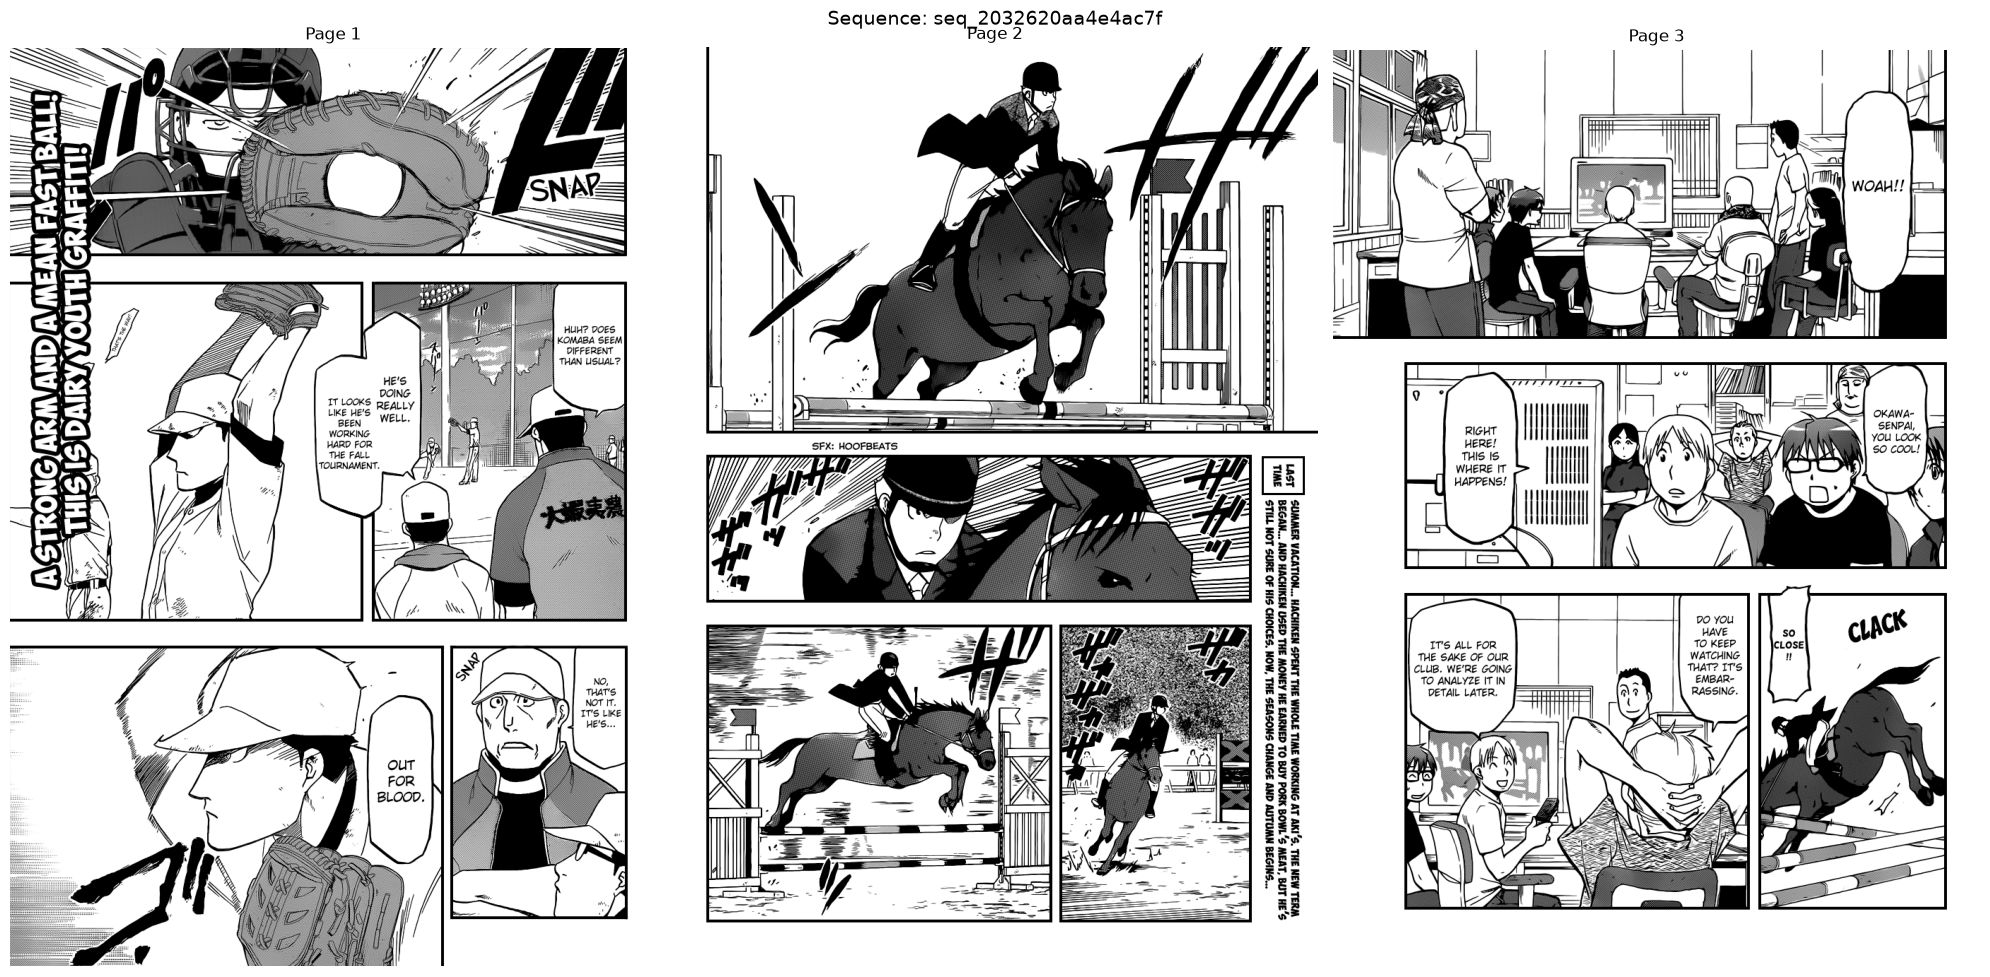

In [7]:
# visualise one image

def show_sequence(seq_id, sequences, labels=None):
    # find sequence
    seq = next(s for s in sequences if s['sequence_id'] == seq_id)
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 10))
    
    for i, img_path in enumerate(seq['images']):
        img = Image.open(BASE / img_path)
        axes[i].imshow(img)
        axes[i].set_title(f"Page {i+1}", fontsize=12)
        axes[i].axis('off')
        
        # show label if available
        if labels and seq_id in labels:
            page_labels = labels[seq_id][i]
            if page_labels:
                label_text = "\n".join([f"{l['speaker']}: {l['text'][:30]}..." 
                                       if len(l['text']) > 30 
                                       else f"{l['speaker']}: {l['text']}" 
                                       for l in page_labels])
            else:
                label_text = "[empty page]"
            axes[i].set_xlabel(label_text, fontsize=8, wrap=True)
    
    plt.suptitle(f"Sequence: {seq_id}", fontsize=14)
    plt.tight_layout()
    plt.show()

# Show first sequence
first_seq_id = dev_sequences[0]['sequence_id']
show_sequence(first_seq_id, dev_sequences, labels)

In [8]:
# dataset statistics

total_lines = 0
empty_pages = 0
unknown_count = 0
narration_count = 0
max_lines = 0
sequences_with_empty = 0

for seq_id, pages in labels.items():
    has_empty = False
    for page in pages:
        if len(page) == 0:
            empty_pages += 1
            has_empty = True
        for item in page:
            total_lines += 1
            if item['speaker'] == 'UNKNOWN':
                unknown_count += 1
            if item['speaker'] == 'NARRATION':
                narration_count += 1
            max_lines = max(max_lines, len(page))
    if has_empty:
        sequences_with_empty += 1

print("#---------------Dataset statictics----------------#")
print(f"Total dialogue lines: {total_lines}")
print(f"Avg lines per sequence: {round(total_lines/80, 1)}")
print(f"Empty pages: {empty_pages} out of {80*3} total pages")
print(f"Sequences with at least one empty page: {sequences_with_empty}")
print(f"UNKNOWN speaker count: {unknown_count}")
print(f"NARRATION count: {narration_count}")
print(f"Max lines on a single page: {max_lines}")

#---------------Dataset statictics----------------#
Total dialogue lines: 1753
Avg lines per sequence: 21.9
Empty pages: 10 out of 240 total pages
Sequences with at least one empty page: 6
UNKNOWN speaker count: 34
NARRATION count: 76
Max lines on a single page: 19


In [9]:
with open(BASE / "sequences.json") as f:
    sequences = json.load(f)

dev_seqs = [s for s in sequences if s['split'] == 'development']

sizes = []
for seq in dev_seqs[:10]:  # check first 10
    for img_path in seq['images']:
        img = Image.open(BASE / img_path)
        sizes.append(img.size)
        
print("Sample image sizes (width x height):")
for s in sizes:
    print(s)

print("\nAll same size: ", len(set(sizes)) == 1)

Sample image sizes (width x height):
(915, 1300)
(914, 1300)
(919, 1300)
(907, 1300)
(908, 1300)
(914, 1300)
(918, 1300)
(911, 1300)
(909, 1300)
(892, 1300)
(897, 1300)
(876, 1300)
(898, 1300)
(893, 1300)
(858, 1300)
(861, 1250)
(872, 1250)
(860, 1250)
(865, 1250)
(868, 1250)
(868, 1250)
(868, 1250)
(863, 1250)
(869, 1250)
(869, 1250)
(864, 1250)
(864, 1250)
(843, 1250)
(848, 1250)
(833, 1250)

All same size:  False


In [10]:
# Check what mode our manga images are.
from PIL import Image
from pathlib import Path
import json

BASE = Path("../dataset")

with open(BASE / "sequences.json") as f:
    sequences = json.load(f)

dev_seqs = [s for s in sequences if s['split'] == 'development']

# Check first 10 images
print("Image modes:")
for seq in dev_seqs[:5]:
    for img_path in seq['images']:
        img = Image.open(BASE / img_path)
        print(f"  {img_path.split('/')[-2]}/{img_path.split('/')[-1]} → mode: {img.mode}, size: {img.size}")

Image modes:
  seq_2032620aa4e4ac7f/01.png → mode: P, size: (915, 1300)
  seq_2032620aa4e4ac7f/02.png → mode: P, size: (914, 1300)
  seq_2032620aa4e4ac7f/03.png → mode: P, size: (919, 1300)
  seq_952f154fb1505883/01.png → mode: P, size: (907, 1300)
  seq_952f154fb1505883/02.png → mode: L, size: (908, 1300)
  seq_952f154fb1505883/03.png → mode: P, size: (914, 1300)
  seq_7db7a000adeceacf/01.png → mode: P, size: (918, 1300)
  seq_7db7a000adeceacf/02.png → mode: P, size: (911, 1300)
  seq_7db7a000adeceacf/03.png → mode: L, size: (909, 1300)
  seq_9032e5551cf1a9d2/01.png → mode: P, size: (892, 1300)
  seq_9032e5551cf1a9d2/02.png → mode: L, size: (897, 1300)
  seq_9032e5551cf1a9d2/03.png → mode: P, size: (876, 1300)
  seq_2022b8c0e1f2d3c0/01.png → mode: P, size: (898, 1300)
  seq_2022b8c0e1f2d3c0/02.png → mode: P, size: (893, 1300)
  seq_2022b8c0e1f2d3c0/03.png → mode: L, size: (858, 1300)


In [11]:
# look at one full sequence visuall
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import json

BASE = Path("../dataset")

with open(BASE / "sequences.json") as f:
    sequences = json.load(f)

with open(BASE / "development/labels.jsonl") as f:
    labels = {}
    for line in f:
        d = json.loads(line)
        labels[d['sequence_id']] = d['pages']

dev_seqs = [s for s in sequences if s['split'] == 'development']

# Pick first sequence
seq = dev_seqs[0]
seq_id = seq['sequence_id']
pages = labels[seq_id]

print(f"Sequence: {seq_id}")

for i, (img_path, page) in enumerate(zip(seq['images'], pages)):
    print(f"\nPage {i+1}:")
    if len(page) == 0:
        print("  [EMPTY - no dialogue]")
    else:
        for line in page:
            print(f"  [{line['speaker']}]: {line['text']}")

Sequence: seq_2032620aa4e4ac7f

Page 1:
  [character1]: HUH? DOES KOMABA SEEM DIFFERENT THAN USUAL?
  [character2]: HE'S DOING REALLY WELL. IT LOOKS LIKE HE'S BEEN WORKING HARD FOR THE FALL TOURNAMENT.
  [UNKNOWN]: THAT'S THE WAY!
  [character1]: NO, THAT'S NOT IT. IT'S LIKE HE'S...
  [character1]: OUT FOR BLOOD.

Page 2:
  [EMPTY - no dialogue]

Page 3:
  [UNKNOWN]: WOAH!!
  [character3]: OKAWA-SENPAI, YOU LOOK SO COOL!
  [character4]: RIGHT HERE! THIS IS WHERE IT HAPPENS!
  [UNKNOWN]: SO CLOSE!!
  [character5]: DO YOU HAVE TO KEEP WATCHING THAT? IT'S EMBARRASSING.
  [character4]: IT'S ALL FOR THE SAKE OF OUR CLUB. WE'RE GOING TO ANALYZE IT IN DETAIL LATER.


In [12]:
# Import Qwen2-VL-7B-Instruct model
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig

In [13]:
# 4-bit Quantization to fit model in GPU memory (~12GB)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True
)

print("loading model...")

model = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-7B-Instruct",
    quantization_config=bnb_config,
    device_map="cuda",
    torch_dtype=torch.float16
)

processor = AutoProcessor.from_pretrained(
    "Qwen/Qwen2-VL-7B-Instruct"
)

print("Model loaded successfully!")
print(f"GPU memory used: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
print(f"GPU memory free: {torch.cuda.memory_reserved()/1024**3:.2f} GB")

loading model...


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

Model loaded successfully!
GPU memory used: 5.53 GB
GPU memory free: 5.58 GB


In [14]:
print(model)

Qwen2VLForConditionalGeneration(
  (model): Qwen2VLModel(
    (visual): Qwen2VisionTransformerPretrainedModel(
      (patch_embed): PatchEmbed(
        (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
      )
      (rotary_pos_emb): Qwen2VLVisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-31): 32 x Qwen2VLVisionBlock(
          (norm1): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
          (norm2): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
          (attn): VisionAttention(
            (qkv): Linear4bit(in_features=1280, out_features=3840, bias=True)
            (proj): Linear4bit(in_features=1280, out_features=1280, bias=True)
          )
          (mlp): VisionMlp(
            (fc1): Linear4bit(in_features=1280, out_features=5120, bias=True)
            (act): QuickGELUActivation()
            (fc2): Linear4bit(in_features=5120, out_features=1280, bias=True)
          )
        )
      )
      (merger): PatchMerger(

In [15]:
# Load sequences
with open(BASE / "sequences.json") as f:
    sequences = json.load(f)

# Load labels
with open(BASE / "development/labels.jsonl") as f:
    labels = {}
    for line in f:
        d = json.loads(line)
        labels[d['sequence_id']] = d['pages']

# Separate dev sequences
dev_seqs = [s for s in sequences if s['split'] == 'development']

# Pick first sequence
seq = dev_seqs[0]
seq_id = seq['sequence_id']

print("Sequence ID:", seq_id)
print("\nGround Truth Page 1:")
for line in labels[seq_id][0]:
    print(f"  [{line['speaker']}]: {line['text']}")

Sequence ID: seq_2032620aa4e4ac7f

Ground Truth Page 1:
  [character1]: HUH? DOES KOMABA SEEM DIFFERENT THAN USUAL?
  [character2]: HE'S DOING REALLY WELL. IT LOOKS LIKE HE'S BEEN WORKING HARD FOR THE FALL TOURNAMENT.
  [UNKNOWN]: THAT'S THE WAY!
  [character1]: NO, THAT'S NOT IT. IT'S LIKE HE'S...
  [character1]: OUT FOR BLOOD.


In [16]:
PROMPT = """You are reading an English manga page. Manga reads RIGHT TO LEFT.

Extract ALL dialogue and narration text in correct reading order (right to left, top to bottom, panel by panel).

INCLUDE:
- Dialogue in speech bubbles
- Internal thoughts in thought bubbles  
- Narration boxes
- Emotional sounds clearly spoken by a character like "WOAH!!" or "UGH!"
- Punctuation only bubbles like "...", "?!", "!"

EXCLUDE:
- Sound effects like SNAP, BOOM, CRASH, WHOOSH, THUD
- Title text, manga name, chapter titles
- Page numbers
- Text on signs, clothes, objects
- Editor notes, translator notes

Speaker labels:
- Use character1, character2 etc for identified characters
- Use UNKNOWN when speaker is not clear
- Use NARRATION for narrator text boxes

If page has zero dialogue output exactly: []

Output ONLY a valid JSON array. Nothing else. No explanation.
Example:
[
  {"speaker": "character1", "text": "Hello!"},
  {"speaker": "NARRATION", "text": "Meanwhile..."}
]"""

print("prompt Ready!")

prompt Ready!


In [17]:
def run_on_page(image_path, prompt, model, processor):
    image = Image.open(image_path).convert("RGB")
    
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": prompt}
            ]
        }
    ]
    
    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    
    inputs = processor(
        text=[text],
        images=[image],
        return_tensors="pt"
    ).to(device)
    
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=1536,
            do_sample=False,
        )
    
    generated_ids = output_ids[0][inputs.input_ids.shape[1]:]
    output_text = processor.decode(generated_ids, skip_special_tokens=True)
    
    return output_text

In [18]:
# run on single image
def run_on_page(image_path, prompt, model, processor):
    image = Image.open(image_path).convert("RGB")
    
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": prompt}
            ]
        }
    ]
    
    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    
    inputs = processor(
        text=[text],
        images=[image],
        return_tensors="pt"
    ).to("cuda")
    
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=1536,
            do_sample=False,
            repetition_penalty=1.0 # repetition penalty to avoid repetition loop
        )
    
    generated_ids = output_ids[0][inputs.input_ids.shape[1]:]
    output_text = processor.decode(generated_ids, skip_special_tokens=True)
    
    return output_text

raw = run_on_page(BASE / seq['images'][0], PROMPT, model, processor)
print(raw)

[
  {"speaker": "NARRATION", "text": "It looks like he's been working hard for the fall tournament."},
  {"speaker": "character2", "text": "He's doing really well."},
  {"speaker": "NARRATION", "text": "Huh? Does Komaba seem different than usual?"},
  {"speaker": "character1", "text": "Out for blood."},
  {"speaker": "NARRATION", "text": "No, that's not it. It's like he's..."}
]


In [19]:
# run on single image

raw2 = run_on_page(BASE / seq['images'][1], PROMPT, model, processor)
print(raw2)

[
  {"speaker": "NARRATION", "text": "LAST TIME... SUMMER VACATION... HACHIKEN SPENT THE WHOLE TIME WORKING AT AKI'S. THE NEW TERM BEGAN... AND HACHIKEN USED THE MONEY HE EARNED TO BUY PORK BOWL'S MEAT. BUT HE'S STILL NOT SURE OF HIS CHOICES. NOW, THE SEASONS CHANGE AND AUTUMN BEGINS..."},
  {"speaker": "NARRATION", "text": "BEGAN... AND HACHIKEN USED THE MONEY HE EARNED TO BUY PORK BOWL'S MEAT. BUT HE'S STILL NOT SURE OF HIS CHOICES. NOW, THE SEASONS CHANGE AND AUTUMN BEGINS..."},
  {"speaker": "NARRATION", "text": "BEGAN... AND HACHIKEN USED THE MONEY HE EARNED TO BUY PORK BOWL'S MEAT. BUT HE'S STILL NOT SURE OF HIS CHOICES. NOW, THE SEASONS CHANGE AND AUTUMN BEGINS..."},
  {"speaker": "NARRATION", "text": "BEGAN... AND HACHIKEN USED THE MONEY HE EARNED TO BUY PORK BOWL'S MEAT. BUT HE'S STILL NOT SURE OF HIS CHOICES. NOW, THE SEASONS CHANGE AND AUTUMN BEGINS..."},
  {"speaker": "NARRATION", "text": "BEGAN... AND HACHIKEN USED THE MONEY HE EARNED TO BUY PORK BOWL'S MEAT. BUT HE'S STIL

In [20]:
# run on single complete sequence 

def run_sequence(seq, prompt, model, processor):
    results = []
    for i, img_rel_path in enumerate(seq['images']):
        print(f"Running page {i+1}...")
        raw = run_on_page(BASE / img_rel_path, prompt, model, processor)
        results.append(raw)
    return results

seq = dev_seqs[0]
seq_id = seq['sequence_id']

raw_outputs = run_sequence(seq, PROMPT, model, processor)

for i, raw in enumerate(raw_outputs):
    print(f"\n=== PAGE {i+1} RAW OUTPUT ===")
    print(raw)

Running page 1...
Running page 2...
Running page 3...

=== PAGE 1 RAW OUTPUT ===
[
  {"speaker": "NARRATION", "text": "It looks like he's been working hard for the fall tournament."},
  {"speaker": "character2", "text": "He's doing really well."},
  {"speaker": "NARRATION", "text": "Huh? Does Komaba seem different than usual?"},
  {"speaker": "character1", "text": "Out for blood."},
  {"speaker": "NARRATION", "text": "No, that's not it. It's like he's..."}
]

=== PAGE 2 RAW OUTPUT ===
[
  {"speaker": "NARRATION", "text": "LAST TIME... SUMMER VACATION... HACHIKEN SPENT THE WHOLE TIME WORKING AT AKI'S. THE NEW TERM BEGAN... AND HACHIKEN USED THE MONEY HE EARNED TO BUY PORK BOWL'S MEAT. BUT HE'S STILL NOT SURE OF HIS CHOICES. NOW, THE SEASONS CHANGE AND AUTUMN BEGINS..."},
  {"speaker": "NARRATION", "text": "BEGAN... AND HACHIKEN USED THE MONEY HE EARNED TO BUY PORK BOWL'S MEAT. BUT HE'S STILL NOT SURE OF HIS CHOICES. NOW, THE SEASONS CHANGE AND AUTUMN BEGINS..."},
  {"speaker": "NARRATIO

In [21]:
def run_on_page(image_path, prompt, model, processor):
    image = Image.open(image_path).convert("RGB")
    messages = [{"role": "user", "content": [
        {"type": "image", "image": image},
        {"type": "text", "text": prompt}
    ]}]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[image], return_tensors="pt").to("cuda")
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=1536,
            do_sample=False,
            no_repeat_ngram_size=8,  # another parameter to avoid repetition penalty
        )
    generated_ids = output_ids[0][inputs.input_ids.shape[1]:]
    return processor.decode(generated_ids, skip_special_tokens=True)

# Test page 1 (want correct character labels)
raw1 = run_on_page(BASE / seq['images'][0], PROMPT, model, processor)
print("=== PAGE 1 ===")
print(raw1)

# Test page 2 (want no looping)
raw2 = run_on_page(BASE / seq['images'][1], PROMPT, model, processor)
print("\n=== PAGE 2 ===")
print(raw2)

=== PAGE 1 ===
[
  {"speaker": "NARRATOR", "text": "It looks like he's been working hard for the fall tournament."},
  {"speaker": "COACH", "text": "Huh? Does Komaba seem different than usual?"},
  {"speaker": "COach", "text": "No, that's not it. It's like he's..."},
  {"speaker": "COACH2", "text": "Out for blood."}
]

=== PAGE 2 ===
[
  {"speaker": "NARRATIVE", "text": "SUMMER VACATION... HACHIKEN SPENT THE WHOLE TIME WORKING AT AKI'S. THE NEW TERM BEGAN... AND HACHIKEN USED THE MONEY HE EARNED TO BUY PORK BOWL'S MEAT, BUT HE'S STILL NOT SURE OF HIS CHOICES. NOW, THE SEASONS CHANGE AND AUTUMN BEGINS..."},
  {"speaker": "NARROW", "text": "LAST TIME"},
  {"speaker": "Narative", "text": "HOOFBEATS"},
  {"speaker": "Narrative", "text": "BEGAN... AND HACHIKEN USED..."},
  {"speaker": "narrative", "text": "THE MONEY HE EARNED TO BUY..."},
  {"speaker": "Narrative", "text": "PORK BOWL'S MEAT, BUT HE'S"},
  {"speaker": "Narration", "text": "STILL NOT SURE OF HIS CHOICES."}
]


In [22]:
# run on single complete sequence 

def run_sequence(seq, prompt, model, processor):
    results = []
    for i, img_rel_path in enumerate(seq['images']):
        print(f"Running page {i+1}...")
        raw = run_on_page(BASE / img_rel_path, prompt, model, processor)
        results.append(raw)
    return results

seq = dev_seqs[0]
seq_id = seq['sequence_id']

raw_outputs = run_sequence(seq, PROMPT, model, processor)

for i, raw in enumerate(raw_outputs):
    print(f"\n=== PAGE {i+1} RAW OUTPUT ===")
    print(raw)

Running page 1...
Running page 2...
Running page 3...

=== PAGE 1 RAW OUTPUT ===
[
  {"speaker": "NARRATOR", "text": "It looks like he's been working hard for the fall tournament."},
  {"speaker": "COACH", "text": "Huh? Does Komaba seem different than usual?"},
  {"speaker": "COach", "text": "No, that's not it. It's like he's..."},
  {"speaker": "COACH2", "text": "Out for blood."}
]

=== PAGE 2 RAW OUTPUT ===
[
  {"speaker": "NARRATIVE", "text": "SUMMER VACATION... HACHIKEN SPENT THE WHOLE TIME WORKING AT AKI'S. THE NEW TERM BEGAN... AND HACHIKEN USED THE MONEY HE EARNED TO BUY PORK BOWL'S MEAT, BUT HE'S STILL NOT SURE OF HIS CHOICES. NOW, THE SEASONS CHANGE AND AUTUMN BEGINS..."},
  {"speaker": "NARROW", "text": "LAST TIME"},
  {"speaker": "Narative", "text": "HOOFBEATS"},
  {"speaker": "Narrative", "text": "BEGAN... AND HACHIKEN USED..."},
  {"speaker": "narrative", "text": "THE MONEY HE EARNED TO BUY..."},
  {"speaker": "Narrative", "text": "PORK BOWL'S MEAT, BUT HE'S"},
  {"speaker

In [23]:
def run_on_page(image_path, prompt, model, processor, max_new_tokens=1536):
    image = Image.open(image_path).convert("RGB")
    messages = [{"role": "user", "content": [
        {"type": "image", "image": image},
        {"type": "text", "text": prompt}
    ]}]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[image], return_tensors="pt").to("cuda")
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            # no repetition_penalty, no no_repeat_ngram_size
        )
    generated_ids = output_ids[0][inputs.input_ids.shape[1]:]
    return processor.decode(generated_ids, skip_special_tokens=True)


def truncate_repetition(raw_text, min_repeat_len=40):
    """
    If a substring of at least `min_repeat_len` characters appears,
    then appears again shortly after, cut everything from the second
    occurrence onward (keep the first, drop the infinite repeat tail).
    """
    n = len(raw_text)
    chunk = raw_text[:min_repeat_len] if n > min_repeat_len else None
    # scan for repeated long chunks
    seen = {}
    i = 0
    while i < n - min_repeat_len:
        snippet = raw_text[i:i+min_repeat_len]
        if snippet in seen:
            # found a repeat starting here -> cut here
            return raw_text[:i]
        seen[snippet] = i
        i += 1
    return raw_text

In [24]:
raw2 = run_on_page(BASE / seq['images'][1], PROMPT, model, processor)
cleaned2 = truncate_repetition(raw2)

print("=== RAW LENGTH:", len(raw2), "===")
print("=== CLEANED LENGTH:", len(cleaned2), "===")
print(cleaned2)

=== RAW LENGTH: 4501 ===
=== CLEANED LENGTH: 327 ===
[
  {"speaker": "NARRATION", "text": "LAST TIME... SUMMER VACATION... HACHIKEN SPENT THE WHOLE TIME WORKING AT AKI'S. THE NEW TERM BEGAN... AND HACHIKEN USED THE MONEY HE EARNED TO BUY PORK BOWL'S MEAT. BUT HE'S STILL NOT SURE OF HIS CHOICES. NOW, THE SEASONS CHANGE AND AUTUMN BEGINS..."},
  {"speaker": "NARRATION", "text": "


In [25]:
raw = run_on_page(BASE / seq['images'][0], PROMPT, model, processor)
cleaned = truncate_repetition(raw)

print("=== RAW LENGTH:", len(raw), "===")
print("=== CLEANED LENGTH:", len(cleaned), "===")
print(cleaned)

=== RAW LENGTH: 381 ===
=== CLEANED LENGTH: 300 ===
[
  {"speaker": "NARRATION", "text": "It looks like he's been working hard for the fall tournament."},
  {"speaker": "character2", "text": "He's doing really well."},
  {"speaker": "NARRATION", "text": "Huh? Does Komaba seem different than usual?"},
  {"speaker": "character1", "text": "Out for blood


In [26]:
import re

def parse_output(raw):
    items = []
    for m in re.finditer(r'\{[^{}]*\}', raw):
        try:
            obj = json.loads(m.group())
        except json.JSONDecodeError:
            continue
        if isinstance(obj, dict) and "speaker" in obj and "text" in obj:
            items.append({"speaker": str(obj["speaker"]).strip(),
                          "text": str(obj["text"]).strip()})
    return items

In [27]:
print("Page 1 parsed:")
for item in parse_output(cleaned):
    print(f"  [{item['speaker']}]: {item['text']}")

print("\nPage 2 parsed:")
for item in parse_output(cleaned2):
    print(f"  [{item['speaker']}]: {item['text']}")

Page 1 parsed:
  [NARRATION]: It looks like he's been working hard for the fall tournament.
  [character2]: He's doing really well.
  [NARRATION]: Huh? Does Komaba seem different than usual?

Page 2 parsed:
  [NARRATION]: LAST TIME... SUMMER VACATION... HACHIKEN SPENT THE WHOLE TIME WORKING AT AKI'S. THE NEW TERM BEGAN... AND HACHIKEN USED THE MONEY HE EARNED TO BUY PORK BOWL'S MEAT. BUT HE'S STILL NOT SURE OF HIS CHOICES. NOW, THE SEASONS CHANGE AND AUTUMN BEGINS...


In [28]:
def truncate_repetition(raw_text, window=60, min_repeats=2): # increase window size to not to miss any text.
    n = len(raw_text)
    i = 0
    while i < n - window:
        snippet = raw_text[i:i+window]
        # count how many times this exact snippet recurs consecutively onward
        count = 1
        j = i + window
        while raw_text[j:j+window] == snippet:
            count += 1
            j += window
            if j >= n:
                break
        if count >= min_repeats:
            return raw_text[:i]
        i += window
    return raw_text

In [29]:
raw1 = run_on_page(BASE / seq['images'][0], PROMPT, model, processor)
cleaned1 = truncate_repetition(raw1)
print("RAW:", len(raw1), "CLEANED:", len(cleaned1))
for item in parse_output(cleaned1):
    print(f"  [{item['speaker']}]: {item['text']}")

raw2 = run_on_page(BASE / seq['images'][1], PROMPT, model, processor)
cleaned2 = truncate_repetition(raw2)
print("\nRAW:", len(raw2), "CLEANED:", len(cleaned2))
for item in parse_output(cleaned2):
    print(f"  [{item['speaker']}]: {item['text']}")

RAW: 381 CLEANED: 381
  [NARRATION]: It looks like he's been working hard for the fall tournament.
  [character2]: He's doing really well.
  [NARRATION]: Huh? Does Komaba seem different than usual?
  [character1]: Out for blood.
  [NARRATION]: No, that's not it. It's like he's...

RAW: 4501 CLEANED: 4501
  [NARRATION]: LAST TIME... SUMMER VACATION... HACHIKEN SPENT THE WHOLE TIME WORKING AT AKI'S. THE NEW TERM BEGAN... AND HACHIKEN USED THE MONEY HE EARNED TO BUY PORK BOWL'S MEAT. BUT HE'S STILL NOT SURE OF HIS CHOICES. NOW, THE SEASONS CHANGE AND AUTUMN BEGINS...
  [NARRATION]: BEGAN... AND HACHIKEN USED THE MONEY HE EARNED TO BUY PORK BOWL'S MEAT. BUT HE'S STILL NOT SURE OF HIS CHOICES. NOW, THE SEASONS CHANGE AND AUTUMN BEGINS...
  [NARRATION]: BEGAN... AND HACHIKEN USED THE MONEY HE EARNED TO BUY PORK BOWL'S MEAT. BUT HE'S STILL NOT SURE OF HIS CHOICES. NOW, THE SEASONS CHANGE AND AUTUMN BEGINS...
  [NARRATION]: BEGAN... AND HACHIKEN USED THE MONEY HE EARNED TO BUY PORK BOWL'S MEAT

In [30]:
def parse_output_dedup(raw):
    items = []
    seen_texts = set()
    for m in re.finditer(r'\{[^{}]*\}', raw):
        try:
            obj = json.loads(m.group())
        except json.JSONDecodeError:
            continue
        if not (isinstance(obj, dict) and "speaker" in obj and "text" in obj):
            continue
        txt = str(obj["text"]).strip()
        # stop entirely once we see a near-duplicate of something already kept
        # (catches both exact repeats and the shifted "BEGAN..." continuation)
        is_dup = any(
            txt in prev or prev in txt or 
            (len(txt) > 20 and txt[:20] == prev[:20])
            for prev in seen_texts
        )
        if is_dup:
            break   # stop at the first sign of a loop, discard everything after
        seen_texts.add(txt)
        items.append({"speaker": str(obj["speaker"]).strip(), "text": txt})
    return items

In [31]:
# page 1 - should still get all 5 lines
print("Page 1:")
for item in parse_output_dedup(raw1):
    print(f"  [{item['speaker']}]: {item['text']}")

# page 2 - should stop after the first (correct) narration line
print("\nPage 2:")
for item in parse_output_dedup(raw2):
    print(f"  [{item['speaker']}]: {item['text']}")

Page 1:
  [NARRATION]: It looks like he's been working hard for the fall tournament.
  [character2]: He's doing really well.
  [NARRATION]: Huh? Does Komaba seem different than usual?
  [character1]: Out for blood.
  [NARRATION]: No, that's not it. It's like he's...

Page 2:
  [NARRATION]: LAST TIME... SUMMER VACATION... HACHIKEN SPENT THE WHOLE TIME WORKING AT AKI'S. THE NEW TERM BEGAN... AND HACHIKEN USED THE MONEY HE EARNED TO BUY PORK BOWL'S MEAT. BUT HE'S STILL NOT SURE OF HIS CHOICES. NOW, THE SEASONS CHANGE AND AUTUMN BEGINS...


In [32]:
def run_sequence_clean(seq, prompt, model, processor):
    page_results = []
    for i, img_rel_path in enumerate(seq['images']):
        print(f"Running page {i+1}...")
        raw = run_on_page(BASE / img_rel_path, prompt, model, processor)
        parsed = parse_output_dedup(raw)
        page_results.append(parsed)
    return page_results

seq = dev_seqs[0]
seq_id = seq['sequence_id']

prediction_pages = run_sequence_clean(seq, PROMPT, model, processor)

for i, page in enumerate(prediction_pages):
    print(f"\n=== PAGE {i+1} PREDICTION ===")
    if len(page) == 0:
        print("  [EMPTY]")
    for item in page:
        print(f"  [{item['speaker']}]: {item['text']}")

print("\n\n=== GROUND TRUTH FOR COMPARISON ===")
for i, page in enumerate(labels[seq_id]):
    print(f"\nPage {i+1}:")
    if len(page) == 0:
        print("  [EMPTY]")
    for item in page:
        print(f"  [{item['speaker']}]: {item['text']}")

Running page 1...
Running page 2...
Running page 3...

=== PAGE 1 PREDICTION ===
  [NARRATION]: It looks like he's been working hard for the fall tournament.
  [character2]: He's doing really well.
  [NARRATION]: Huh? Does Komaba seem different than usual?
  [character1]: Out for blood.
  [NARRATION]: No, that's not it. It's like he's...

=== PAGE 2 PREDICTION ===
  [NARRATION]: LAST TIME... SUMMER VACATION... HACHIKEN SPENT THE WHOLE TIME WORKING AT AKI'S. THE NEW TERM BEGAN... AND HACHIKEN USED THE MONEY HE EARNED TO BUY PORK BOWL'S MEAT. BUT HE'S STILL NOT SURE OF HIS CHOICES. NOW, THE SEASONS CHANGE AND AUTUMN BEGINS...

=== PAGE 3 PREDICTION ===
  [UNKNOWN]: WOAH!!
  [OKAWA-SENPAI]: OKAWA-SENPAI, YOU LOOK SO COOL!
  [OKAWA-SENPAI]: IT'S ALL FOR THE SAKE OF OUR CLUB. WE'RE GOING TO ANALYZE IT IN DETAIL LATER.
  [UNKNOWN]: DO YOU HAVE TO KEEP WATCHING THAT? IT'S EMBARRASSING.
  [UNKNOWN]: SO CLOSE!!
  [UNKNOWN]: CLACK


=== GROUND TRUTH FOR COMPARISON ===

Page 1:
  [character1]: HU

In [34]:
# run on entire dev sequences.

import re, json, time
from pathlib import Path
from PIL import Image
import torch

LIMIT = None          # set to 3 for a quick smoke test, None for all 80
OUT_DIR = Path("../outputs")
OUT_DIR.mkdir(exist_ok=True)
PRED_PATH = OUT_DIR / "baseline_predictions.jsonl"
RAW_PATH  = OUT_DIR / "baseline_raw.jsonl"     # raw model text, for re-parsing later


def run_on_page(image_path, prompt, model, processor, max_new_tokens=1536):
    image = Image.open(image_path).convert("RGB")
    messages = [{"role": "user", "content": [
        {"type": "image", "image": image},
        {"type": "text", "text": prompt},
    ]}]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[image], return_tensors="pt").to("cuda")
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    gen = output_ids[0][inputs.input_ids.shape[1]:]
    return processor.decode(gen, skip_special_tokens=True)


def parse_output_dedup(raw):
    items, seen = [], []
    for m in re.finditer(r'\{[^{}]*\}', raw):
        try:
            obj = json.loads(m.group())
        except json.JSONDecodeError:
            continue
        if not (isinstance(obj, dict) and "speaker" in obj and "text" in obj):
            continue
        txt = str(obj["text"]).strip()
        spk = str(obj["speaker"]).strip()
        if spk.upper() in ("UNKNOWN", "NARRATION"):   # fix casing only
            spk = spk.upper()
        if any(txt in p or p in txt or (len(txt) > 20 and txt[:20] == p[:20]) for p in seen):
            break                                      # loop detected, discard the rest
        seen.append(txt)
        items.append({"speaker": spk, "text": txt})
    return items


done_ids = set()
if PRED_PATH.exists():
    with open(PRED_PATH) as f:
        done_ids = {json.loads(l)["sequence_id"] for l in f}
    print(f"Resuming: {len(done_ids)} sequences already done")

todo = [s for s in dev_seqs if s["sequence_id"] not in done_ids]
if LIMIT:
    todo = todo[:LIMIT]
print(f"Sequences to run: {len(todo)}")

# ---------- main loop ----------#
start = time.time()
with open(PRED_PATH, "a") as pred_f, open(RAW_PATH, "a") as raw_f:
    for n, seq in enumerate(todo, 1):
        raws, pages = [], []
        for rel in seq["images"]:
            raw = run_on_page(BASE / rel, PROMPT, model, processor)
            raws.append(raw)
            pages.append(parse_output_dedup(raw))

        pred_f.write(json.dumps({"sequence_id": seq["sequence_id"], "pages": pages}) + "\n")
        raw_f.write(json.dumps({"sequence_id": seq["sequence_id"], "raw": raws}) + "\n")
        pred_f.flush(); raw_f.flush()

        elapsed = time.time() - start
        eta = (len(todo) - n) * (elapsed / n) / 60
        print(f"[{n}/{len(todo)}] {seq['sequence_id']}  {elapsed/60:.1f} min elapsed, ~{eta:.1f} min left")

print("Done.")

Sequences to run: 80
[1/80] seq_2032620aa4e4ac7f  0.7 min elapsed, ~52.6 min left
[2/80] seq_952f154fb1505883  1.1 min elapsed, ~44.4 min left
[3/80] seq_7db7a000adeceacf  1.5 min elapsed, ~38.9 min left
[4/80] seq_9032e5551cf1a9d2  1.8 min elapsed, ~34.7 min left
[5/80] seq_2022b8c0e1f2d3c0  2.6 min elapsed, ~39.6 min left
[6/80] seq_a3bd36201a0cd61b  3.8 min elapsed, ~46.4 min left
[7/80] seq_72fdfff4b4353a42  4.1 min elapsed, ~42.8 min left
[8/80] seq_b251c8e1ba8b91f8  4.5 min elapsed, ~40.5 min left
[9/80] seq_ee880b9612205860  4.9 min elapsed, ~38.8 min left
[10/80] seq_06ec0acde37dffa4  5.3 min elapsed, ~37.3 min left
[11/80] seq_1c1d4f5e71a2f554  5.9 min elapsed, ~36.9 min left
[12/80] seq_032cbb4dc8686963  6.3 min elapsed, ~35.7 min left
[13/80] seq_f164203a45862778  6.9 min elapsed, ~35.3 min left
[14/80] seq_dcebdbbf614a9b4d  7.1 min elapsed, ~33.7 min left
[15/80] seq_2fae297a18af2a57  7.5 min elapsed, ~32.4 min left
[16/80] seq_d8afceb0e8f9122d  7.7 min elapsed, ~30.6 min l